In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [8]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 20
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [12]:
# Random distribution
np.random.seed(1)

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = x_scale * np.random.rand(N_chamber)
y_nodes = y_scale * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Characteristic node separation distance
node_sep = z_scale/(N_chamber - 1)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=0.0,
                    p0=0.0,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

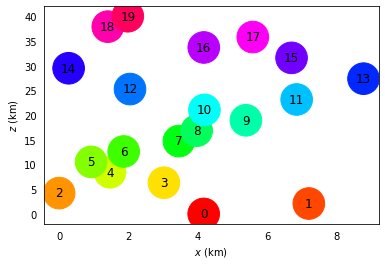

In [ ]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=1e2,
                                   R_outer_ratio=20,
                                   max_edge_dist=10*node_sep)

# Source term due to mass injection at node 0
f_inj = global_sys.create_single_mass_injection_source(1.0)
# Source term due to eruption at node -1
f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)

global_sys.show_network(global_sys.q0)

In [29]:
node_sep

2105.2631578947367

In [104]:
def run_sim(dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=9e9)

  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(1.0)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)

  t_vec = np.linspace(0, 10e11, 20000)
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)
  m, p, u = global_sys.compute_m_p_u(q_out)

  return (t_vec, m, p, u, q_out, m_erupted_out, global_sys)

In [105]:
# dpdx_crit_range = np.geomspace(1e1, 1e5, 6)
dpdx_crit_range = np.geomspace(50, 4000, 24)
sim_list = [run_sim(dpdx_crit) for dpdx_crit in dpdx_crit_range]

In [ ]:
# Data backup
# import os
# os.chdir("D:/")
# for i in range(len(sim_list)):
#   np.savez_compressed(f"sim_setAug1_{i}.npz",
#                       t_vec=sim_list[i][0],
#                       m=sim_list[i][1],
#                       p=sim_list[i][2],
#                       u=sim_list[i][3],
#                       q_out=sim_list[i][4],
#                       m_erupted_out=sim_list[i][5])

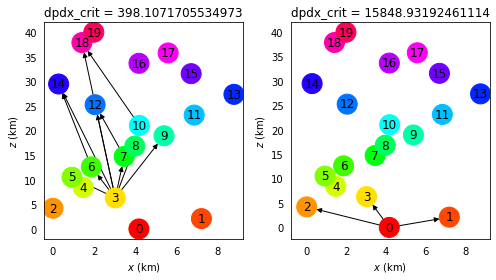

In [ ]:
plt.figure(figsize=(7,4))
plt.subplot(1,2,1)
sim_list[2][6].show_network(sim_list[2][4][-200,:], 400)
plt.title(f"dpdx_crit = {dpdx_crit_range[2]}")
plt.subplot(1,2,2)
sim_list[4][6].show_network(sim_list[4][4][-200,:], 400)
plt.title(f"dpdx_crit = {dpdx_crit_range[4]}")
plt.tight_layout()

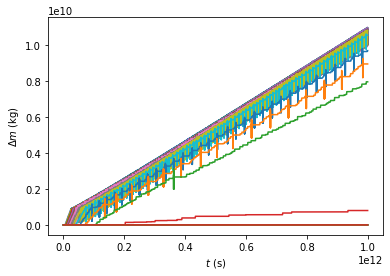

In [111]:
for i in range(24):
  plt.plot(sim_list[i][0], sim_list[i][1][:,-1] - sim_list[i][1][0,-1])
  plt.xlabel(r"$t$ (s)")
  plt.ylabel(r"$\Delta m$ (kg)")

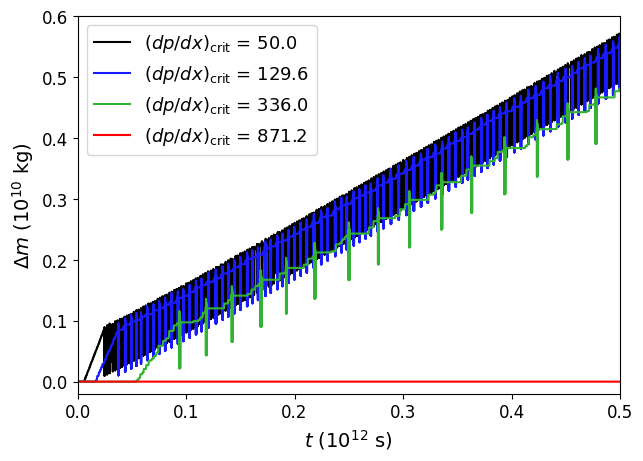

In [245]:
t_scale = 1e12
mass_scale = 1e10
line_colors = [
  [0,0,0],
  [.10,0.10,1],
  [.2,.7,.2],
  [1,0,0],
]
plt.figure(figsize=(7,5), dpi=100)
for plot_i, i in enumerate(range(0,20,5)):
  plt.plot(sim_list[i][0]/t_scale,
           (sim_list[i][1][:,-1] - sim_list[i][1][0,-1])/mass_scale,
           color=line_colors[plot_i], label=f"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[i]:.1f}")
  plt.xlabel(r"$t$ ($10^{12}$ s)", fontsize=14)
  plt.ylabel(r"$\Delta m$ ($10^{10}$ kg)", fontsize=14)
plt.gca().tick_params(axis="both", labelsize=12)
plt.xlim(0, 0.5)
plt.ylim(-0.02, .6)
plt.legend(fontsize=13)


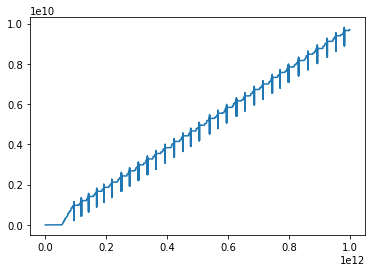

In [112]:
i = 10
plt.plot(sim_list[i][0], sim_list[i][1][:,-1] - sim_list[i][1][0,-1])

In [113]:
dpdx_crit_range[10]

336.04731786442966

In [114]:
def run_sim_acc(dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=9e9)

  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(1.0)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)

  t_vec = np.linspace(0, 10e11, 40000)
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)
  m, p, u = global_sys.compute_m_p_u(q_out)

  return (t_vec, m, p, u, q_out, m_erupted_out, global_sys)

sim_acc = run_sim_acc(dpdx_crit_range[10])

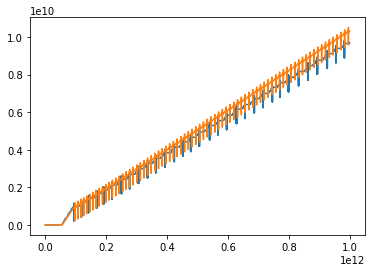

In [115]:
plt.plot(sim_list[i][0], sim_list[i][1][:,-1] - sim_list[i][1][0,-1])
plt.plot(sim_acc[0], sim_acc[1][:,-1] - sim_acc[1][0,-1])


(200000000000.0, 400000000000.0)

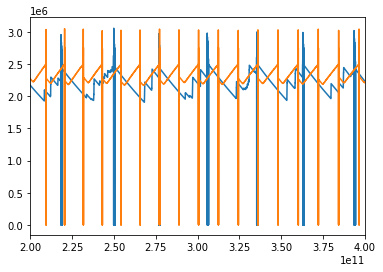

In [117]:
plt.plot(sim_list[i][0], sim_list[i][2][:,-1] - sim_list[i][2][0,-1])
plt.plot(sim_acc[0], sim_acc[2][:,-1] - sim_acc[2][0,-1])
plt.xlim(.2e12,.4e12)

In [123]:
# (t_vec, m, p, u, q_out, m_erupted_out, global_sys)
_t, _m, _p, _u, _q, _m, _global_sys = sim_acc
# Get system size information
Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

In [247]:
def get_time_averaged_connectivity(_t, _m, _p, _u, _q, _m_out, _global_sys, averaged=True):
  Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

  Y = np.zeros((_t.size, num_blocks, num_blocks))

  def smoother(x, scale):
    ''' Returns one-sided compact smoothed step, such that
      1. u(x < -scale) = 0
      2. u(x >= 0) = 1.
      3. u smoothly interpolates from 0 to 1 in between.
    '''
    # Shift, scale, and clip to [-1, 0] to prevent exp overflow
    if scale != 0:
      _x = np.clip(x / scale + 1, 0, 1)
    else:
      _x = np.where(x >= 0, 1, 0)
    f0 = np.exp(-1/np.where(_x == 0, 1, _x))
    f1 = np.exp(-1/np.where(_x == 1, 1, 1-_x))
    # Return piecewise evaluation
    return np.where(_x >= 1, 1,
          np.where(_x <= 0, 0, 
          f0 / (f0 + f1)))

  for i in range(num_blocks):
    node_i = _global_sys.nodes[i]
    for j in range(num_blocks):
      if i == j:
        continue
      node_j = _global_sys.nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > _global_sys.max_edge_dist:
        continue
      # Compute average pressure gradient
      dpdx = (_p[:,i] - _p[:,j]) / dist
      # Resolve remote tensile stress in x-direction
      opening_stress = _global_sys.remote_sigma_xx * np.abs(node_i.z - node_j.z)/ dist
      # Effective pressure gradient
      dpdx_eff = dpdx
      # Effective critical pressure gradient for opening
      dpdx_crit_eff = _global_sys.dpdx_crit - opening_stress

      # Factor between (0, 1) that modulates flow between the two chambers
      if dpdx_crit_eff != 0:
        threshold_factor = smoother(np.abs(dpdx_eff) - dpdx_crit_eff,
                                    _global_sys.dpdx_threshold_scale) * (dpdx_eff > 0).astype(float)
        if np.any(threshold_factor > 1) or np.any(threshold_factor < 0):
          raise ValueError
      else:
        threshold_factor = np.ones_like(dpdx_eff)

      # Compute flow admittance ( (m/s) / Pa )
      Y[:,i,j] = threshold_factor * _global_sys.r_hydr * _global_sys.r_hydr / 16.0 / _global_sys.mu0 / dist

  if averaged:
    return Y.mean(axis=0)
  else:
    return Y

In [193]:
np.linalg.norm(get_time_averaged_connectivity(*sim_acc) - Y_time_averaged)

0.0

Text(0.5, 1.0, '$(dp/dx)_\\mathrm{crit}$ = 2259 Pa / m')

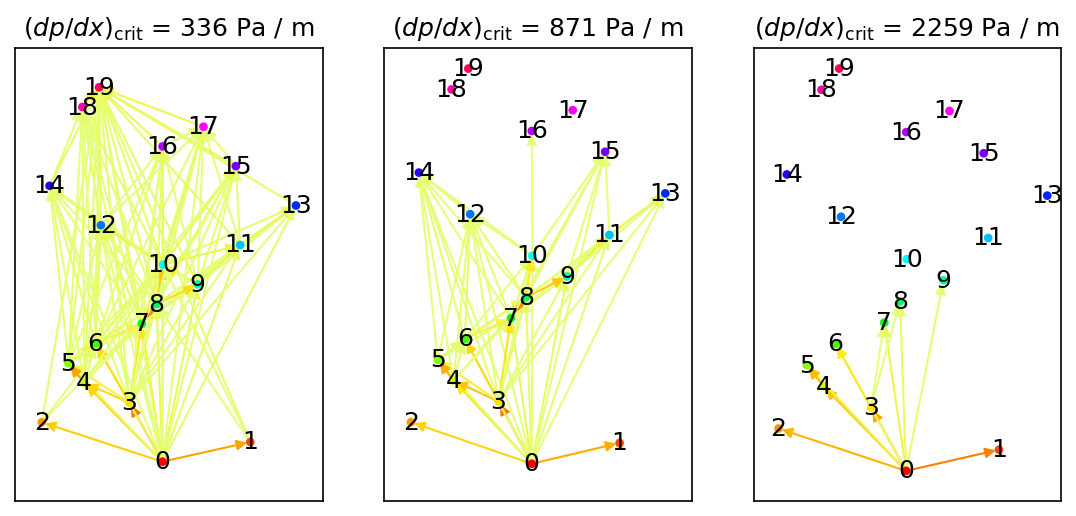

In [210]:
import networkx as nx

def shadow_plot(sim:tuple):
  # Scaled edge connectivity
  Y_time_averaged = get_time_averaged_connectivity(*sim)
  edge_intensity = (np.array(scipy.sparse.csr_matrix(Y_time_averaged).data))
  edge_intensity /= edge_intensity.max()
  edge_intensity **= 0.8
  G = nx.DiGraph(Y_time_averaged)

  # Node index-position mapping (2D projection)
  length_scale = 1e3
  pos = {i:(n.x / length_scale, n.z / length_scale,)
         for (i, n) in enumerate(_global_sys.nodes)}
  V_nodes = np.array([node.V for node in _global_sys.nodes])
  node_scale = 10
  colors = matplotlib.cm.hsv(np.linspace(0,1,num_blocks,endpoint=False))
  node_size = node_scale*V_nodes/V_nodes.max()

  
  nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
          edge_cmap=matplotlib.cm.Wistia,
          edge_color=edge_intensity)
  
plt.figure(figsize=(9,4), dpi=150)
plt.subplot(1,3,1)
shadow_plot(sim_list[10])
plt.title(rf"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[10]:.0f} Pa / m")
plt.subplot(1,3,2)
shadow_plot(sim_list[15])
plt.title(rf"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[15]:.0f} Pa / m")
plt.subplot(1,3,3)
shadow_plot(sim_list[20])
plt.title(rf"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[20]:.0f} Pa / m")


[(15, 17), (15, 19), (16, 17), (16, 19), (17, 19), (18, 19)]

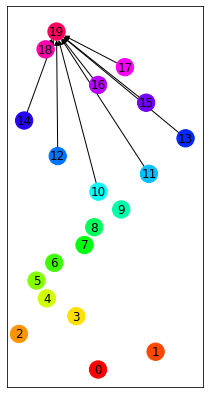

In [332]:
plt.figure(figsize=(3.5,7))
_t, _m, _p, _u, _q, _m_out, _global_sys = sim_list[10]


# Scaled edge connectivity
Y_time_averaged = get_time_averaged_connectivity(*sim_list[10])

G = nx.DiGraph(Y_time_averaged)

# Node index-position mapping (2D projection)
length_scale = 1e3
pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(_global_sys.nodes)}
V_nodes = np.array([node.V for node in _global_sys.nodes])
node_scale = 300
colors = matplotlib.cm.hsv(np.linspace(0,1,num_blocks,endpoint=False))
node_size = node_scale*V_nodes/V_nodes.max()

node_colors = matplotlib.cm.hsv(np.linspace(0,1,_global_sys.num_blocks,endpoint=False))
# Filter edges with average conductivity at least 10% of the edge with the max
Y_time_averaged_cut = (Y_time_averaged[:,-1] > 0.1 * Y_time_averaged[:,-1].max()
                       ).astype(float)[:,np.newaxis] * Y_time_averaged
Y_time_averaged_cut[:,:-1] = 0
nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
                 edgelist=list(nx.DiGraph(Y_time_averaged_cut).edges()))

(0.0, 0.5)

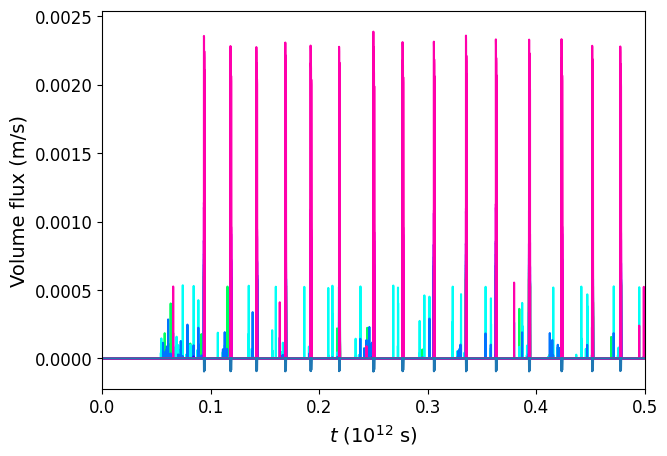

In [ ]:
# Interrogate chamber -1, flow rates in and out
line_colors = [
  [0,0,0],
  [.10,0.10,1],
  [.2,.7,.2],
  [1,0,0],
]
Y = get_time_averaged_connectivity(*sim_list[10], averaged=False)
_t, _m, _p, _u, _q, _m_out, _global_sys = sim_list[10]
# Compute volume flow rate to chamber #-1
u_in = Y[:,:,-1] * (_p[:,:] - _p[:,-1:])

t_scale = 1e12

plt.figure(figsize=(7,5), dpi=100)
for i in range(u_in.shape[1]):
  plt.plot(_t/t_scale, u_in[:,i] * _global_sys.rho0 * np.pi * _global_sys.r_hydr**2, color=node_colors[i])
plt.xlim(.2e12, .3e12)

plt.plot(0.5*(_t[1:] + _t[:-1]) / t_scale,
         -np.diff(_m_out) / np.diff(_t) / (np.pi * _global_sys.r_hydr**2 * _global_sys.rho0))


plt.xlabel(r"$t$ ($10^{12}$ s)", fontsize=14)
plt.ylabel(r"Mass rate (kg/s)", fontsize=14)
plt.gca().tick_params(axis="both", labelsize=12)
plt.xlim(0, 0.5)

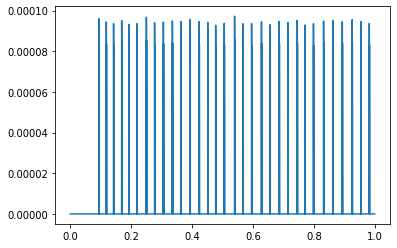

Single

In [22]:
t_vec = np.linspace(0, 5e11, 10000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

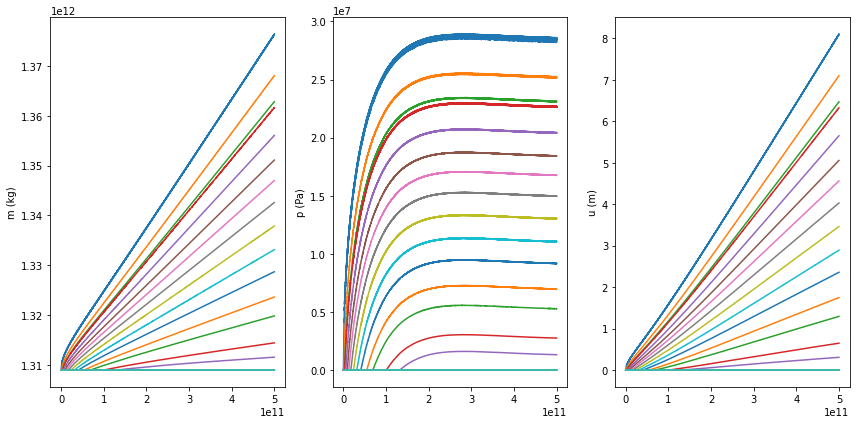

In [24]:
m, p, u = global_sys.compute_m_p_u(q_out)
fig, ax = plt.subplots(1, 3, figsize=(12,6))

max_plot_index = -1
ax[0].plot(t_vec[:max_plot_index], m[:max_plot_index])
ax[1].plot(t_vec[:max_plot_index], p[:max_plot_index])
ax[2].plot(t_vec[:max_plot_index], u[:max_plot_index])

ax[0].set_ylabel("m (kg)")
ax[1].set_ylabel("p (Pa)")
ax[2].set_ylabel("u (m)")
fig.tight_layout()

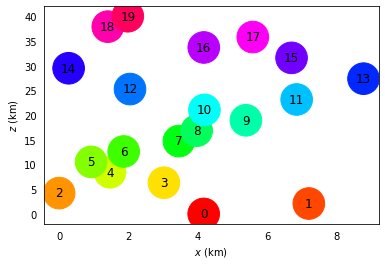

In [ ]:
q_out.shape
global_sys.show_network(global_sys.q0[:,-1],)


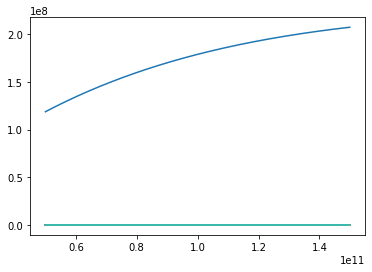

In [17]:
max_plot_index = 1000
plt.plot(t_vec[1000:3000], p[1000:3000])


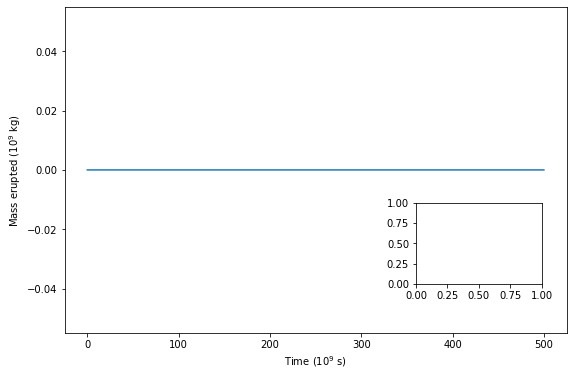

In [18]:
plt.figure(figsize=(9,6))
plt.plot(t_vec/1e9, m_erupted_out/1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Mass erupted ($10^9$ kg)")

axin1 = plt.gca().inset_axes([0.7, 0.15, 0.25, 0.25])

# axin2 = plt.gca().inset_axes([5, 7, 2.3, 2.3], transform=ax.transData)

(60.0, 70.0)

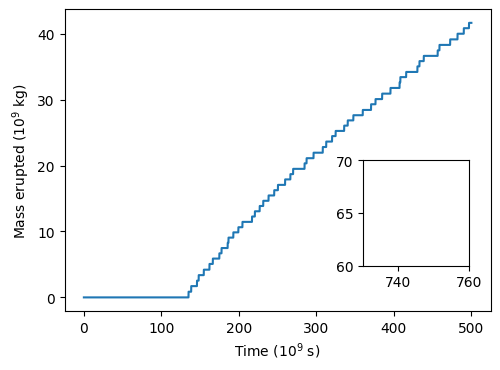

In [12]:
plt.figure(figsize=(5.5,4), dpi=100)
plt.plot(t_vec/1e9, m_erupted_out/1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Mass erupted ($10^9$ kg)")

inset_axes = plt.gca().inset_axes([0.7, 0.15, 0.25, 0.35])
inset_axes.plot(t_vec/1e9, m_erupted_out/1e9, '.-')
inset_axes.set_xlim(730,760)
inset_axes.set_ylim(60,70)


Text(0, 0.5, '$\\Delta t/dt$')

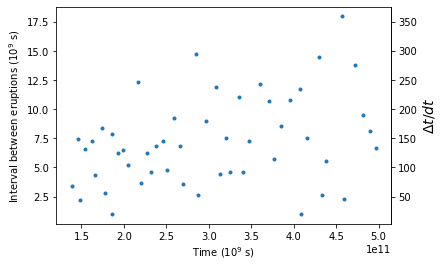

In [13]:

# Binarize eruption rates
is_erupting = np.diff(m_erupted_out) > 0
# Interval-centered times
t_vec_centered = 0.5*(t_vec[1:] + t_vec[:-1])

# Time picks for eruptions
t_eruptions = t_vec_centered[is_erupting]
# Inter-eruption intervals
t_eruption_intervals = np.diff(t_eruptions)

plt.plot(t_eruptions[1:], t_eruption_intervals/1e9, '.')
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Interval between eruptions ($10^9$ s)")
# Estimate dpdt
dt = t_vec[1] - t_vec[0]
ax2y = plt.gca().secondary_yaxis('right', functions=(
  lambda t: 1e9 * t / dt,
  lambda tau: tau * dt / 1e9))
ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

#### Melt focusing

#### Testing

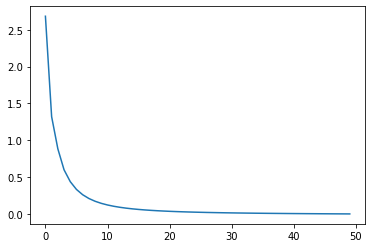

In [27]:
# Pick sample q for testing
q = q_out[-1,:]
# Extract state vector q for top node
q_loc = q[(global_sys.num_blocks-1) * global_sys.block_size:
          global_sys.num_blocks * global_sys.block_size]
# Compute max discharge from pressure
top_node = global_sys.nodes[-1]
# Compute displacement field for top node
u = (top_node.H @ q_loc + top_node.k.ravel())
plt.plot(u)

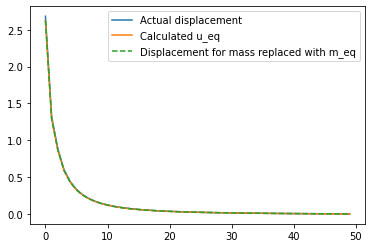

In [28]:
''' Compute displacement field after instantaneous depressurization to p0
and associated residual mass.'''

# Outer product matrix representing effect of mass on bdry displacement
outer = scipy.sparse.lil_matrix((global_sys.Nr, global_sys.Nr,))
outer[:,0] = 3 * top_node.m0 / top_node.R0 * top_node.H[:,global_sys.data_slice["mass"]]
# Compute operator q -> m_equilibrium, with the form m_eq = H_mod @ q + k_mod
H_mod = scipy.sparse.linalg.spsolve_triangular(
  scipy.sparse.eye(global_sys.Nr, global_sys.Nr) - outer,
  top_node.H.todense(),
  lower=True)
# Compute modified k
k_mod =  scipy.sparse.linalg.spsolve_triangular(
  scipy.sparse.eye(global_sys.Nr, global_sys.Nr) - outer,
  top_node.k,
  lower=True)
# Move dependence on mass in input q to dependence on m0
k_mod += H_mod[:, global_sys.data_slice["mass"]] * top_node.m0
H_mod[:, global_sys.data_slice["mass"]] = 0
# Finalize types of H, k
H_mod = scipy.sparse.csr_matrix(H_mod)
# k_mod = k_mod.toarray()

plt.plot((top_node.H @ q_loc).ravel() + (top_node.k).ravel())
plt.plot((H_mod @ q_loc).ravel() + (k_mod).ravel())

# Compute elastic equilibrium
u_eq = H_mod @ q_loc + k_mod.squeeze()
m_eq = top_node.m0 * (1 + 3 * u_eq[0] / top_node.R0)

# Test a vector where the mass is replaced by the equilibrium mass
q_test = q_loc.copy()
q_test[global_sys.data_slice["mass"]] = m_eq
u_test = top_node.H @ q_test + top_node.k.squeeze()
plt.plot(u_test, '--')

plt.legend([
  "Actual displacement",
  "Calculated u_eq",
  "Displacement for mass replaced with m_eq",
])